## Roll No   : 12000187
#### Name : RAGESHWER SINGH
### Subject : Data Pre-processing [Trimester : 1 (MSc Data Science and AI)]

This assignment features the preprocessing and cleaning of a FIFA player statistic dataset. The final goal is to achieve a dataset ready for future use in ML.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All initial libraries imported successfully.")

All initial libraries imported successfully.


# TASK A
The task is to :<br>
1. Describe the data set at hand (the data points and the features).<br>
2. Classify the features/attributes as numeric(discrete or continuous) or categorical(nominal or ordinal).<br>
3. Create a dictionary for features explaining their types and description.

The dataset has a total of 77 columns(attributes) with 18979 rows(data points or players). Out of the 77 columns, 54 are numeric and 23 (including the 'Hits' column) are non numeric.
The 'Hits' attribute was mixed, so, for better view, I have first converted it to string type. For this assignment target : OVA (Overall Rating)


In [45]:
df=pd.read_csv('fifa21_datatset.csv',dtype={'Hits':str})
print(df.shape)
print(df.columns)
df.head()

(18979, 77)
Index(['ID', 'Name', 'LongName', 'photoUrl', 'playerUrl', 'Nationality', 'Age',
       '↓OVA', 'POT', 'Club', 'Contract', 'Positions', 'Height', 'Weight',
       'Preferred Foot', 'BOV', 'Best Position', 'Joined', 'Loan Date End',
       'Value', 'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing',
       'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling',
       'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement',
       'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance',
       'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots',
       'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle',
       'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling',
       'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats',
       'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS',
       'D

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,\n\n\n\nManchester City,...,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,...,High,Medium,5 ★,91,85,86,94,36,59,595


In [46]:
# The columns that have missing or null values:
null_columns=df.isna().sum()
null_columns=null_columns[null_columns>0]
print(null_columns)

Loan Date End    17966
Hits              2595
dtype: int64


In [47]:
# The attributes having numerical values:
numeric_col=df.select_dtypes(include=['number']).columns
print(len(numeric_col))
print(numeric_col)

54
Index(['ID', 'Age', '↓OVA', 'POT', 'BOV', 'Attacking', 'Crossing', 'Finishing',
       'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling',
       'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement',
       'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance',
       'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots',
       'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle',
       'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling',
       'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats',
       'Base Stats', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY'],
      dtype='str')


In [48]:
# The categorical/string attributes:
string_col=df.select_dtypes(include=['str']).columns
print(len(string_col))
print(string_col)

23
Index(['Name', 'LongName', 'photoUrl', 'playerUrl', 'Nationality', 'Club',
       'Contract', 'Positions', 'Height', 'Weight', 'Preferred Foot',
       'Best Position', 'Joined', 'Loan Date End', 'Value', 'Wage',
       'Release Clause', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'Hits'],
      dtype='str')


#### Finding attributes that should be numerical:
Upon seeing the list of string attributes, there are some columns that should have been numerical in nature. So, in order to better classify the attributes, they are being explored.

In [49]:
temp_df=df[['Height','Weight','Contract','Joined','Value','Wage','Hits','IR','W/F','SM','A/W','D/W','Release Clause']]
temp_df.head()

,Height,Weight,Contract,Joined,Value,Wage,Hits,IR,W/F,SM,A/W,D/W,Release Clause
0,170cm,72kg,2004 ~ 2021,"Jul 1, 2004",€103.5M,€560K,771,5 ★,4 ★,4★,Medium,Low,€138.4M
1,187cm,83kg,2018 ~ 2022,"Jul 10, 2018",€63M,€220K,562,5 ★,4 ★,5★,High,Low,€75.9M
2,188cm,87kg,2014 ~ 2023,"Jul 16, 2014",€120M,€125K,150,3 ★,3 ★,1★,Medium,Medium,€159.4M
3,181cm,70kg,2015 ~ 2023,"Aug 30, 2015",€129M,€370K,207,4 ★,5 ★,4★,High,High,€161M
4,175cm,68kg,2017 ~ 2022,"Aug 3, 2017",€132M,€270K,595,5 ★,5 ★,5★,High,Medium,€166.5M


The IR, WF, SM are ordinal attributes and the columns height, weight, value, wage, release clause and hits should be numerical. I am correcting the inconsistencies (and converting these into numeric) in these columns here in the start to improve the classification and further exploration of data. Correct classification in to numeric and categorical in the start will simplify the cleaning ahead.
Following is the conversion of some attributes to numeric columns.<br>
Correction of 'Height' attribute:

In [50]:
# Correction of height
unique_values=np.array(df['Height'].unique())
print(unique_values)
# The height is represented as feet and inches.
# Split '5\'11"' into 5 and 11 and convert accordingly to 'cm'
df['Height']=df['Height'].replace(['cm'],'',regex=True)
df['Height']=df['Height'].replace(['\''],' ',regex=True)
df['Height']=df['Height'].replace(['"'],'',regex=True)

def feet_cm(string):
    str_list=string.split()
    if len(str_list)>1:
        res=[int(x) for x in str_list]
        cm=res[0]*30.48 + res[1]*2.54
        return float(cm)
    else :
         return float(str_list[0])

df['Height']=df['Height'].apply(feet_cm)
print("After Correction:")
unique_values=np.array(df['Height'].unique())
print(unique_values)

['170cm' '187cm' '188cm' '181cm' '175cm' '184cm' '191cm' '178cm' '193cm'
 '185cm' '199cm' '173cm' '168cm' '176cm' '177cm' '183cm' '180cm' '189cm'
 '179cm' '195cm' '172cm' '182cm' '186cm' '192cm' '165cm' '194cm' '167cm'
 '196cm' '163cm' '190cm' '174cm' '169cm' '171cm' '197cm' '200cm' '166cm'
 '6\'2"' '164cm' '198cm' '6\'3"' '6\'5"' '5\'11"' '6\'4"' '6\'1"' '6\'0"'
 '5\'10"' '5\'9"' '5\'6"' '5\'7"' '5\'4"' '201cm' '158cm' '162cm' '161cm'
 '160cm' '203cm' '157cm' '156cm' '202cm' '159cm' '206cm' '155cm']
After Correction:
[170.   187.   188.   181.   175.   184.   191.   178.   193.   185.
 199.   173.   168.   176.   177.   183.   180.   189.   179.   195.
 172.   182.   186.   192.   165.   194.   167.   196.   163.   190.
 174.   169.   171.   197.   200.   166.   187.96 164.   198.   190.5
 195.58 180.34 193.04 185.42 182.88 177.8  175.26 167.64 170.18 162.56
 201.   158.   162.   161.   160.   203.   157.   156.   202.   159.
 206.   155.  ]


Correction of 'Weight':

In [51]:
# Correction of weight
unique_values=np.array(df['Weight'].unique())
print(unique_values)
# The values have suffix 'kg' or 'lbs'. For this assignment 'kg' will be the conventional metric.
df['Weight']=df['Weight'].replace('kg','',regex=True)

# Convert lbs to kg
def lbs_kg(string):
    if 'lbs' in string:
        str1=float(string[0:-3]) * 0.453
        return str1
    else :
        return float(string)
    
df['Weight']=df['Weight'].apply(lbs_kg)

print("After Correction:")
unique_values=np.array(df['Weight'].unique())
print(unique_values)

['72kg' '83kg' '87kg' '70kg' '68kg' '80kg' '71kg' '91kg' '73kg' '85kg'
 '92kg' '69kg' '84kg' '96kg' '81kg' '82kg' '75kg' '86kg' '89kg' '74kg'
 '76kg' '64kg' '78kg' '90kg' '66kg' '60kg' '94kg' '79kg' '67kg' '65kg'
 '59kg' '61kg' '93kg' '88kg' '97kg' '77kg' '62kg' '63kg' '95kg' '100kg'
 '58kg' '183lbs' '179lbs' '172lbs' '196lbs' '176lbs' '185lbs' '170lbs'
 '203lbs' '168lbs' '161lbs' '146lbs' '130lbs' '190lbs' '174lbs' '148lbs'
 '165lbs' '159lbs' '192lbs' '181lbs' '139lbs' '154lbs' '157lbs' '163lbs'
 '98kg' '103kg' '99kg' '102kg' '56kg' '101kg' '57kg' '55kg' '104kg'
 '107kg' '110kg' '53kg' '50kg' '54kg' '52kg']
After Correction:
[ 72.     83.     87.     70.     68.     80.     71.     91.     73.
  85.     92.     69.     84.     96.     81.     82.     75.     86.
  89.     74.     76.     64.     78.     90.     66.     60.     94.
  79.     67.     65.     59.     61.     93.     88.     97.     77.
  62.     63.     95.    100.     58.     82.899  81.087  77.916  88.788
  79.728  83.

Correction of 'Value':

In [52]:
# Conversion of value
unique_values=np.array(df['Value'].unique())
print(unique_values)

df['Value']=df['Value'].replace('€','',regex=True)

def value_player(string):
    if 'M' in string:
        return float(string[:-1])*(10**6) 
    elif 'K' in string:
        return float(string[:-1])*1000
    else :
        return float(string)
        
df['Value']=df['Value'].apply(value_player) 

print("After Correction:")
unique_values=np.array(df['Value'].unique())
print(unique_values)   
print(df['Value'].head())                        

['€103.5M' '€63M' '€120M' '€129M' '€132M' '€111M' '€120.5M' '€102M'
 '€185.5M' '€110M' '€113M' '€90.5M' '€82M' '€17.5M' '€83.5M' '€33.5M'
 '€114.5M' '€78M' '€103M' '€109M' '€92M' '€10M' '€76.5M' '€89.5M' '€87.5M'
 '€79.5M' '€124M' '€114M' '€95M' '€92.5M' '€105.5M' '€88.5M' '€85M'
 '€81.5M' '€26M' '€21M' '€56M' '€67.5M' '€53M' '€36.5M' '€51M' '€65.5M'
 '€46.5M' '€61.5M' '€72.5M' '€77.5M' '€43.5M' '€32.5M' '€36M' '€32M'
 '€54M' '€49.5M' '€57M' '€66.5M' '€74.5M' '€71.5M' '€121M' '€99M' '€67M'
 '€86.5M' '€93.5M' '€70M' '€62M' '€66M' '€58M' '€44M' '€81M' '€37M'
 '€14.5M' '€46M' '€47.5M' '€52.5M' '€54.5M' '€34.5M' '€57.5M' '€51.5M'
 '€44.5M' '€55M' '€48M' '€60.5M' '€63.5M' '€61M' '€29M' '€58.5M' '€55.5M'
 '€42M' '€40.5M' '€43M' '€45.5M' '€34M' '€26.5M' '€42.5M' '€35.5M' '€45M'
 '€41.5M' '€40M' '€11M' '€13.5M' '€29.5M' '€27M' '€15.5M' '€38.5M' '€52M'
 '€33M' '€19M' '€73.5M' '€38M' '€35M' '€47M' '€24M' '€30.5M' '€18M' '€28M'
 '€25.5M' '€25M' '€31M' '€23.5M' '€30M' '€31.5M' '€22.5M' '€28.5M' '€

Correction of 'Wage':

In [53]:
# Convert wage
unique_values=np.array(df['Wage'].unique())
print(unique_values)

df['Wage']=df['Wage'].replace('€','',regex=True)

def wage_player(string):
    if 'K' in string:
        return float(string[:-1])*(1000) 
    else :
        return float(string)

df['Wage']=df['Wage'].apply(wage_player)

print("After Correction:")
unique_values=np.array(df['Wage'].unique())
print(unique_values)

['€560K' '€220K' '€125K' '€370K' '€270K' '€240K' '€250K' '€160K' '€260K'
 '€210K' '€310K' '€130K' '€350K' '€300K' '€190K' '€145K' '€195K' '€100K'
 '€140K' '€290K' '€82K' '€110K' '€230K' '€155K' '€200K' '€165K' '€95K'
 '€170K' '€105K' '€115K' '€150K' '€135K' '€55K' '€58K' '€81K' '€34K'
 '€120K' '€59K' '€90K' '€65K' '€56K' '€71K' '€18K' '€75K' '€47K' '€20K'
 '€84K' '€86K' '€74K' '€78K' '€27K' '€68K' '€85K' '€25K' '€46K' '€83K'
 '€54K' '€79K' '€175K' '€43K' '€49K' '€45K' '€38K' '€41K' '€39K' '€23K'
 '€51K' '€50K' '€87K' '€30K' '€14K' '€69K' '€31K' '€64K' '€53K' '€35K'
 '€21K' '€28K' '€17K' '€33K' '€70K' '€32K' '€89K' '€26K' '€40K' '€76K'
 '€72K' '€48K' '€36K' '€29K' '€60K' '€16K' '€37K' '€24K' '€52K' '€0'
 '€62K' '€73K' '€63K' '€19K' '€1K' '€66K' '€80K' '€12K' '€2K' '€42K'
 '€13K' '€900' '€57K' '€77K' '€61K' '€22K' '€67K' '€44K' '€15K' '€11K'
 '€8K' '€850' '€10K' '€88K' '€500' '€7K' '€6K' '€9K' '€5K' '€700' '€950'
 '€750' '€3K' '€650' '€600' '€4K' '€800' '€550']
After Correction:
[5.60e+0

Conversion of Release Clause:

In [54]:
# Upon exploring the unique values in Release Clause, they are of the forms : numberM or numberK

df['Release Clause']=df['Release Clause'].replace('€','',regex=True)

def rel_cla(string):
    if 'M' in string:
        str1=float(string[:-1]) * (10**6)
        return str1
    elif 'K' in string:
        str1=float(string[:-1]) * (1000)
        return str1
    else : 
        return float(string)

df['Release Clause']=df['Release Clause'].apply(rel_cla)

Correction of 'Hits' column:

In [55]:
# Convert Hits
unique_values=np.array(df['Hits'].unique())
print(unique_values)

# It has null values that for now I keep
# To convert hits to integer value we must use astype('Int64') that supports NaN as integer

def hit_num(string):
    if 'K' in string:
        str1=float(string[:-1])*1000
        return int(str1)
    else:
        return int(string)
df['Hits']=df['Hits'].dropna().apply(hit_num)
df['Hits']=df['Hits'].astype('Int64')

print("After Correction:")
unique_values=np.array(df['Hits'].unique())
print(unique_values)

['771' '562' '150' '207' '595' '248' '246' '120' '1.6K' '130' '321' '189'
 '175' '96' '118' '216' '212' '154' '205' '202' '339' '408' '103' '332'
 '86' '173' '161' '396' '1.1K' '433' '242' '206' '177' '1.5K' '198' '459'
 '117' '119' '209' '84' '187' '165' '203' '65' '336' '126' '313' '124'
 '145' '538' '182' '101' '45' '377' '99' '194' '403' '414' '593' '374'
 '245' '3.2K' '266' '299' '309' '215' '265' '211' '112' '337' '70' '159'
 '688' '116' '63' '144' '123' '71' '224' '113' '168' '61' '89' '137' '278'
 '75' '148' '176' '197' '264' '214' '247' '402' '440' '1.7K' '2.3K' '171'
 '320' '657' '87' '259' '200' '255' '253' '196' '60' '97' '85' '169' '256'
 '132' '239' '166' '121' '109' '32' '46' '122' '48' '527' '199' '282' '51'
 '1.9K' '642' '155' '323' '288' '497' '509' '79' '49' '270' '511' '80'
 '128' '115' '156' '204' '143' '140' '152' '220' '134' '225' '94' '74'
 '135' '142' '50' '77' '40' '107' '193' '179' '34' '64' '453' '57' '81'
 '28' '78' '133' '43' '425' '88' '42' '36' '233' '37

Updating the new numeric and categorical columns:

In [56]:
# Updating the new numeric and string/categorical columns:
numeric_col=df.select_dtypes(include=['number']).columns
string_col=df.select_dtypes(include=['str']).columns
print(numeric_col)
print(string_col)
df.info()

Index(['ID', 'Age', '↓OVA', 'POT', 'Height', 'Weight', 'BOV', 'Value', 'Wage',
       'Release Clause', 'Attacking', 'Crossing', 'Finishing',
       'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling',
       'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement',
       'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance',
       'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots',
       'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle',
       'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling',
       'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats',
       'Base Stats', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Hits'],
      dtype='str')
Index(['Name', 'LongName', 'photoUrl', 'playerUrl', 'Nationality', 'Club',
       'Contract', 'Positions', 'Preferred Foot', 'Best Position', 'Joined',
       'Loan Date End'

### Classification of attributes:
The data types that theoretically have no gap, meaning infinite amount of values can come in between 2 values are considered as continuous. Here, the attributes height,weight,value and wage can be considered continuous.
The columns with float dtype generally can be considered as continuous. 


In [57]:
float_col=df.select_dtypes(include='float').columns
print(float_col)

Index(['Height', 'Weight', 'Value', 'Wage', 'Release Clause'], dtype='str')


The difference between the nominal and ordinal attributes is that the ordinal attributes have a ranking, eg High, Med and Low. Generally, the ordinal attributes will have less number of unique values.

In [58]:
# Calculation of unique values in each column
print("Number of unique values in string attributes :")
num_unique=[]
for col in string_col:
    num_unique.append(len(df[col].unique()))
num_unique=pd.DataFrame(num_unique,index=string_col,columns=['Unique'])
print(num_unique.sort_values(by='Unique'))

Number of unique values in string attributes :
                Unique
Preferred Foot       2
A/W                  3
D/W                  3
SM                   5
W/F                  5
IR                   5
Best Position       15
Loan Date End       25
Contract           131
Nationality        164
Positions          640
Club               682
Joined            1869
Name             17920
LongName         18852
playerUrl        18979
photoUrl         18979


The attributes Preferred Foot, Best Position and Loan End date could not be considered as ordinal attributes as their values cannot be ordered. The AW,DW,SM,WF and IR attributes have values that can be ordered.

In [59]:
ordinal=['A/W','D/W','SM','W/F','IR']
df[ordinal].head()


,A/W,D/W,SM,W/F,IR
0,Medium,Low,4★,4 ★,5 ★
1,High,Low,5★,4 ★,5 ★
2,Medium,Medium,1★,3 ★,3 ★
3,High,High,4★,5 ★,4 ★
4,High,Medium,5★,5 ★,5 ★


Below is the <B>DICTIONARY TABLE</B> (Data Frame) for attributes that calssifies the type of data it has and its description.

In [60]:
# Data Dict Table
Features=[df.columns]
Type=['Ordinal Data' if col in ordinal else
      'Continuous Numeric Data' if col in float_col else
      'Discrete Numeric Data' if col in numeric_col else
      'Nominal Data'
      for col in df.columns 
     ]
Description=[
          f"The attribute {col} contains ordinal types. These have an order but cannot be compared." if col in ordinal else
          f"The column {col} contains continuous data types, specifically {'float'}" if col in float_col else
          f"The feature {col} contains Discrete data types : {'int64'}" if col in numeric_col else
          f"The {col} contains categorical nominal data."
          for col in df.columns 
          ]


feature_df=pd.DataFrame({
    'Type':Type,
    'Description':Description
},index=Features)

# We can find information about any attribute in the dictionary.
print(feature_df.loc['IR'])
print()
print("The whole feature dictionary/data frame :")
print(feature_df.to_string())


            Type                                        Description
IR  Ordinal Data  The attribute IR contains ordinal types. These...

The whole feature dictionary/data frame :
                                     Type                                                                            Description
ID                  Discrete Numeric Data                                    The feature ID contains Discrete data types : int64
Name                         Nominal Data                                            The Name contains categorical nominal data.
LongName                     Nominal Data                                        The LongName contains categorical nominal data.
photoUrl                     Nominal Data                                        The photoUrl contains categorical nominal data.
playerUrl                    Nominal Data                                       The playerUrl contains categorical nominal data.
Nationality                  Nominal Data      

# TASK B
In this task, I am going to anlyze the data quality. The task is <br>
1. To find and remove any duplicate data points.<br> 
2. Find the missing and noisy values. <br>
3. Explore the outliers and their impact.<br>

### Duplicate data points:

In [61]:
dup_rows=df.duplicated().sum()
print(dup_rows)
# There are no duplicate data points.


0


### Finding and Visualizing missing values:

In [62]:
# We have already framed a series object showing columns with null values.
print(null_columns)
# There are only 2 columns that have null values.

Loan Date End    17966
Hits              2595
dtype: int64


In [63]:
# First explore what kind of values they possess.
print(df[['Loan Date End','Hits']].head())

# The Hits column has already been converted to integer. This is a type of dicrete data and for some players, Hits value is missing.

print("\nUnique values in the loan date end attribute:")
unique_lde=np.array(df['Loan Date End'].unique())
print(unique_lde)
# The "loan date end" attribute has huge number of missing values. The type of data in this attribute features date. Later this can be converted to a binary type data with 0: Not on loan and 1: On loan.
# The interesting point to note is weather these dates (for players on loan) matches with the contract date end. This will be looked into later.

  Loan Date End  Hits
0           NaN   771
1           NaN   562
2           NaN   150
3           NaN   207
4           NaN   595

Unique values in the loan date end attribute:
[nan 'Jun 30, 2021' 'Dec 31, 2020' 'Jan 30, 2021' 'Jun 30, 2022'
 'May 31, 2021' 'Jul 5, 2021' 'Dec 31, 2021' 'Jul 1, 2021' 'Jan 1, 2021'
 'Aug 31, 2021' 'Jan 31, 2021' 'Dec 30, 2021' 'Jun 23, 2021' 'Jan 3, 2021'
 'Nov 27, 2021' 'Jan 17, 2021' 'Jun 30, 2023' 'Jul 31, 2021'
 'Nov 22, 2020' 'May 31, 2022' 'Dec 30, 2020' 'Jan 4, 2021' 'Nov 30, 2020'
 'Aug 1, 2021']


Visualizing the missing values:

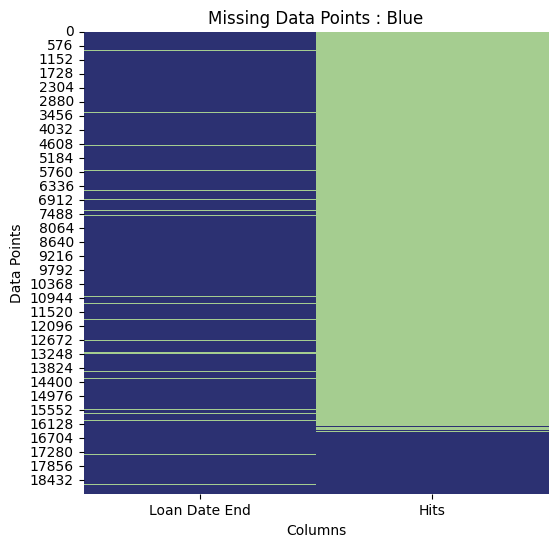

In [64]:
# Lets visualize the missing values in both the values:
plt.figure(figsize=(6,6))
sns.heatmap(df[['Loan Date End','Hits']].isnull(),cmap='crest',cbar=False)
plt.title("Missing Data Points : Blue")
plt.xlabel("Columns")
plt.ylabel("Data Points")
plt.show()

### Analyzing the noise:
Noise in a dataset is a collection of inconsistencies, meaningless attributes and invalid values that hampers the accuracy of our model. The missing values and outliers (actual rare values) will be handled separately in cleaning. Following is the exploration of inconsistencies(label formamts), invalid values and not usefull attributes.<br>


Analysis of irrelevant attributes:

In [65]:
# Lets look at categorical columns first

string_col
# Name, LongName, photoUrl, playerUrl, Joined are irrelevant for determining OVA.
# Features like : Contract can affect Value, Preffered Foot affects Positions (eg left for right wing). So they are kept.

Index(['Name', 'LongName', 'photoUrl', 'playerUrl', 'Nationality', 'Club',
       'Contract', 'Positions', 'Preferred Foot', 'Best Position', 'Joined',
       'Loan Date End', 'W/F', 'SM', 'A/W', 'D/W', 'IR'],
      dtype='str')

In [66]:
numeric_col
# ID has no impact on OVA.

Index(['ID', 'Age', '↓OVA', 'POT', 'Height', 'Weight', 'BOV', 'Value', 'Wage',
       'Release Clause', 'Attacking', 'Crossing', 'Finishing',
       'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling',
       'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement',
       'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance',
       'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots',
       'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle',
       'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling',
       'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats',
       'Base Stats', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Hits'],
      dtype='str')

Analysis of inconsistencies and invalid(or out of range) values:<br>
<br>
The attributes with numerical values (int and float) need to be checked for invalid (out of range) values, missing values and outliers only because, for attributes that have number as values, the inconsistency in metrics used (eg : lbs in place of KG) can only be detected with outliers. 
During the classification of attributes into categorical or numeric in Task A, the inconsistensies in the Height, Weight, Value, Wage, Release Clause and Hits columns were taken care of. They were identified because they had the data type String and the metric used was mentioned in the data itself.<br>
<br>


Inconsistencies in categorical columns:

In [67]:
# Removing the irrelevant columns from categorical attributes:
irr_col=['Name','LongName','photoUrl','playerUrl','Joined']
temp_df2=df[string_col].drop(irr_col,axis=1)

# The unique values in each categorical column
for col in temp_df2.columns:
    unique=np.array(temp_df2[col].unique())
    print()
    print(f"Col :{col}")
    print(unique)



Col :Nationality
['Argentina' 'Portugal' 'Slovenia' 'Belgium' 'Brazil' 'Poland' 'Egypt'
 'France' 'Germany' 'Netherlands' 'Senegal' 'Spain' 'England' 'Scotland'
 'Korea Republic' 'Costa Rica' 'Italy' 'Gabon' 'Croatia' 'Uruguay'
 'Switzerland' 'Serbia' 'Slovakia' 'Morocco' 'Algeria' 'Denmark' 'Hungary'
 'Bosnia Herzegovina' 'Nigeria' 'Cameroon' 'Norway' 'Ghana' 'Mexico'
 'Austria' 'Albania' 'Colombia' 'Chile' 'Ivory Coast' 'Greece' 'Finland'
 'Wales' 'Sweden' 'Togo' 'Czech Republic' 'Russia' 'Venezuela' 'Canada'
 'United States' 'Guinea' 'Montenegro' 'Israel' 'Republic of Ireland'
 'Ukraine' 'Turkey' 'Ecuador' 'Jamaica' 'DR Congo' 'Australia' 'China PR'
 'Armenia' 'Northern Ireland' 'North Macedonia' 'Kosovo' 'Mali' 'Peru'
 'Central African Republic' 'Iceland' 'Burkina Faso' 'Paraguay' 'Japan'
 'Romania' 'New Zealand' 'Iran' 'Angola' 'Tunisia' 'Syria'
 'Dominican Republic' 'Cape Verde' 'Equatorial Guinea' 'Kenya' 'Georgia'
 'Panama' 'Zambia' 'Tanzania' 'Zimbabwe' 'Congo' 'South Africa'

Attributes with inconsistencies:<br>
1. Contract : The attribute features contract periods of players (or "Free") or the end date of the loan in the same column in string format.
2. Loan End Date : This attribute in current form is not as impactfull as when it is converted to binary (on loan/not on loan).
3. Club and Nationality : The names of clubs and nations are unique and label encoding can be applied without cleaning names. (One hot coding increases columns.)

### Detecting outliers and their impact:

In [68]:
# Using IQR (Inter Quartile Range) to detect outliers:

Q1=df[numeric_col].quantile(0.25)
Q3=df[numeric_col].quantile(0.75)
IQR=Q3-Q1
l_bound=Q1 - 1.5*IQR
u_bound=Q3 + 1.5*IQR

outliers=df[(df[numeric_col]<l_bound) | (df[numeric_col]>u_bound)]
num_out=outliers.notna().sum()
num_out=num_out[num_out>0]
print(num_out.sort_values(ascending=False))

Release Clause      2851
Wage                2356
Value               2297
Hits                2202
Goalkeeping         2181
GK Kicking          2089
GK Positioning      2086
GK Diving           2085
GK Reflexes         2085
GK Handling         2085
Ball Control        2053
Attacking           2016
Dribbling           1962
Short Passing       1748
Mentality           1493
Skill               1233
Heading Accuracy    1108
Stamina              878
Acceleration         782
Sprint Speed         710
Movement             667
Total Stats          620
DRI                  441
Jumping              412
PAC                  334
Balance              269
ID                   250
Agility              228
Composure            184
PAS                  181
Reactions            181
↓OVA                 156
POT                  153
BOV                  137
Strength             133
PHY                  117
Weight                74
Vision                71
Power                 59
Base Stats            48


The IQR uses a fixed cutoff to separate the outliers. The attributes like Value, Wage and Hits can be right skewed depending on the player. Some attributes related to Goalkeeping (GK Kicking, Diving Reflexes etc) provide high scores to only goalkeepers which are lesser in number. Skill related abilities also have high score related to player's position and quality (eg: Defenders (Right Backs RB) would have less score in Attacking).

Box Plot of the columns that have more than 2100 outliers :<br>

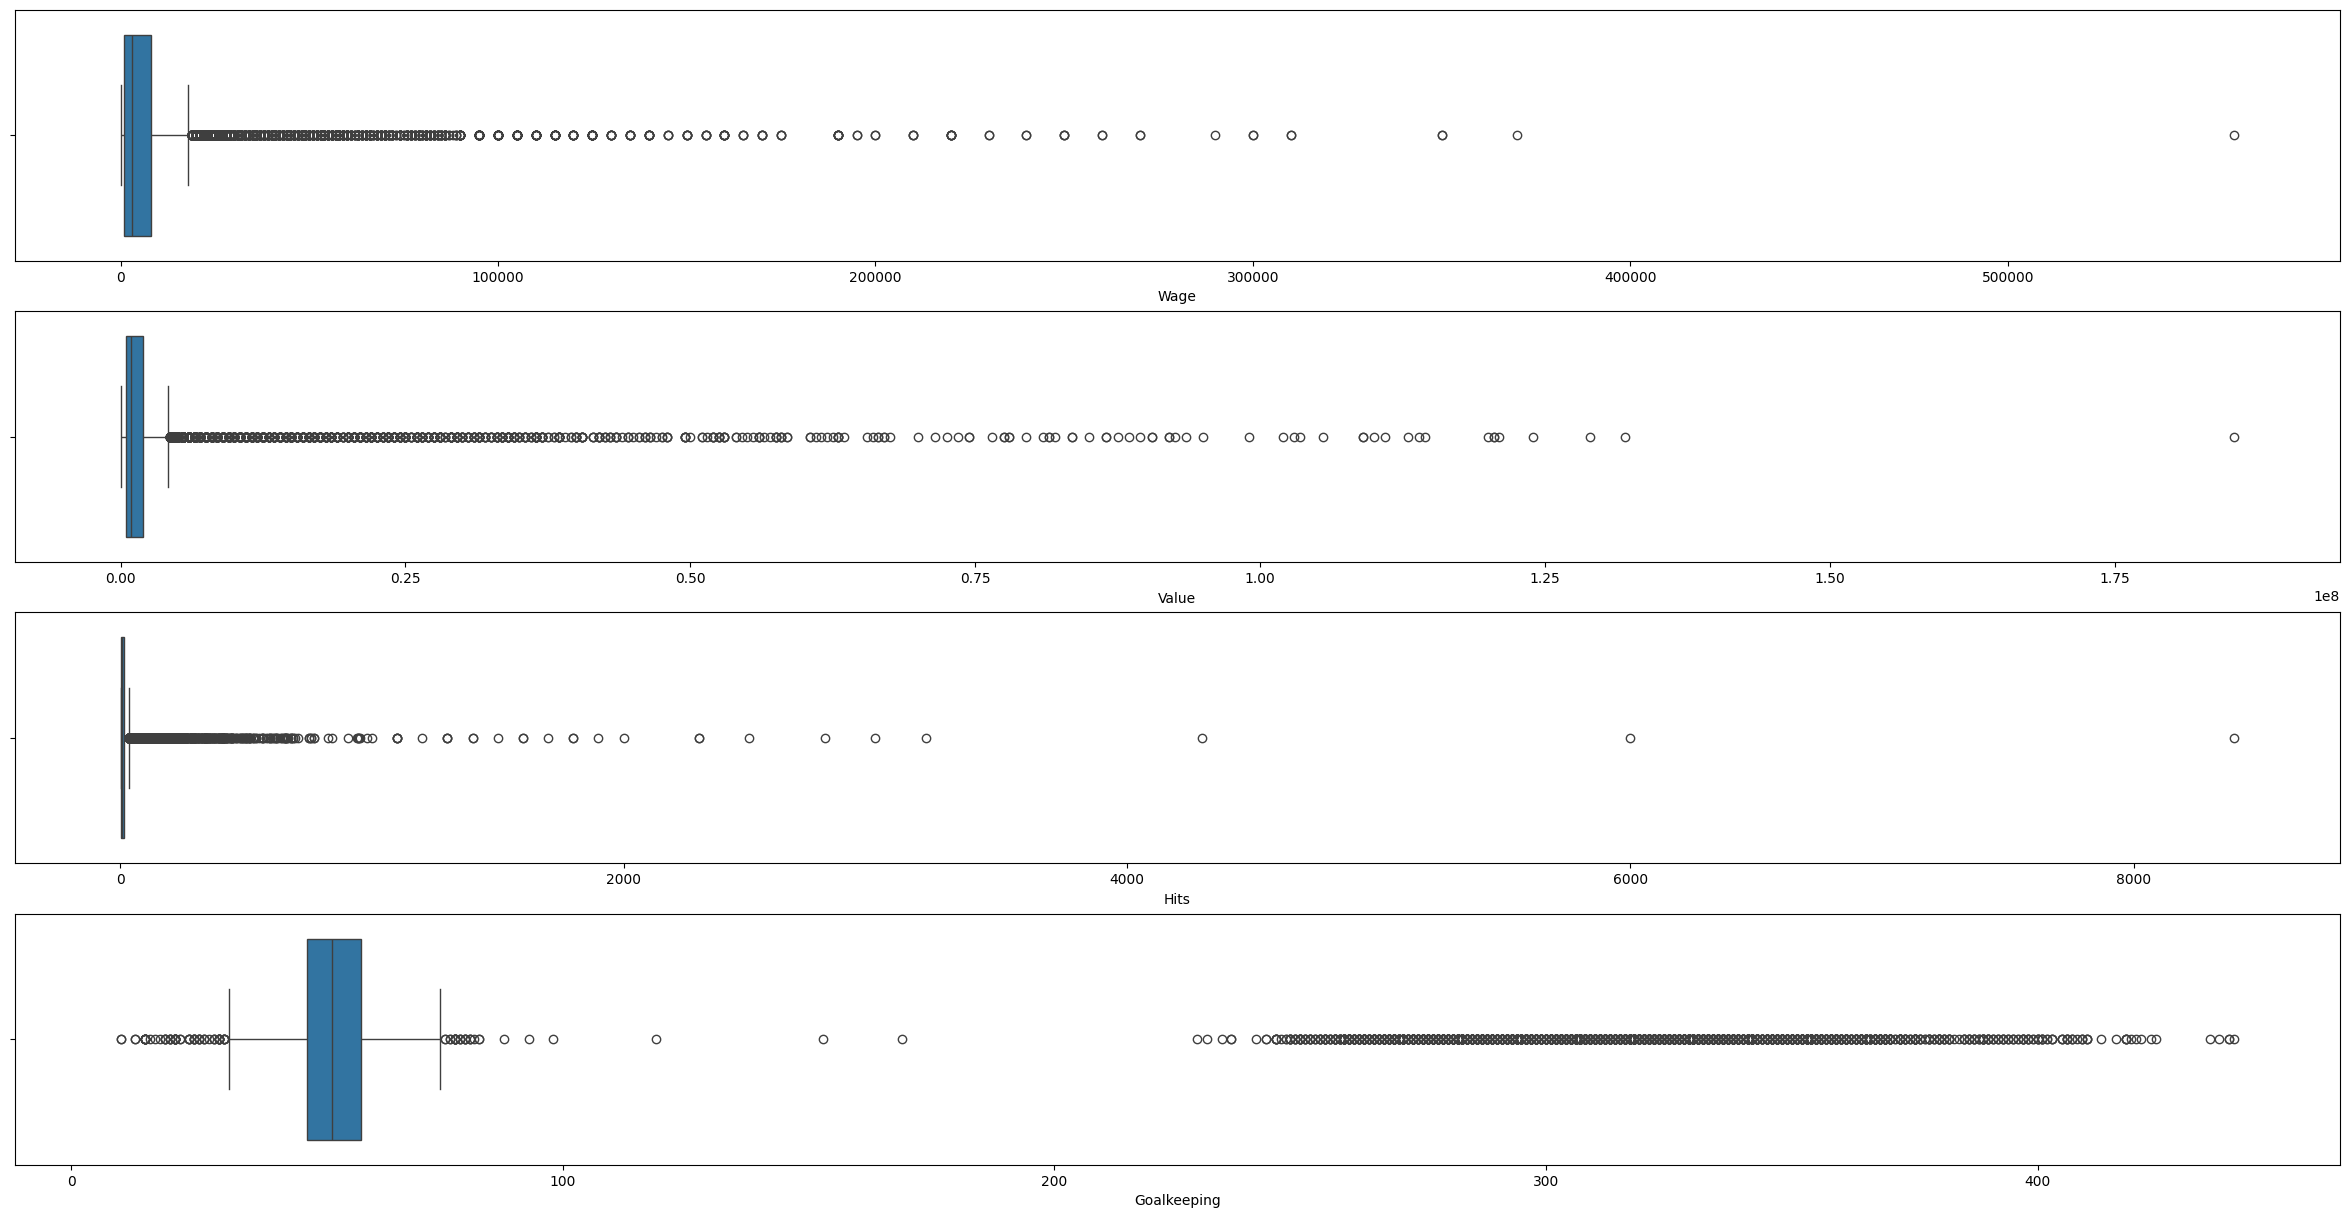

In [69]:
out_col=['Wage','Value','Hits','Goalkeeping']
fig, axes = plt.subplots(nrows=4,ncols=1,figsize=(30,15))

for i,col in enumerate(out_col):
    sns.boxplot(x=df[col],ax=axes[i])
    
plt.show()

# TASK C
## Data Cleaning
The task is to perform :
1. Handling of missing values.
1. Handle inconsistencies.

### Handling of missing values:
Only 2 attributes have missing values:<br>
<br>
Handling of missing values in Loan Date End : 

In [70]:
# Handling of Loan Date End:
# The intuition is that "Loan Date End" consist of contract end dates for players on loan. If they are similar then this column can be converted into binary (0 : not on loan and 1 : on loan) as the 
# values are similar to 'Contract' column.

# Checking weather "Contract" and "Loan date end" have same date for players on loan:
temp_df3=df[['Contract','Loan Date End']]
temp_df3=temp_df3.dropna()

# The Contract column has "On Loan" suffix for players on loan
def remove_onloan(string):
    str1=string[:-8]
    return str1

temp_df3['Contract']=temp_df3['Contract'].apply(remove_onloan)

mis_matches=(temp_df3['Contract'].values!=temp_df3['Loan Date End'].values).sum()
print(f"The values in the 'Loan Date End' column matches with 'Contract' with number of mismatches :{mis_matches}")

The values in the 'Loan Date End' column matches with 'Contract' with number of mismatches :0


In [71]:
# Creating a new column 'On Loan' and removing 'Loan Date End':
def map_onloan(string):
    if pd.notnull(string):
        return 1
    else:
        return 0

df['On Loan']=df['Loan Date End'].apply(map_onloan)
df=df.drop('Loan Date End',axis=1)


Handling of missing values in 'Hits' column:<br>


<Axes: >

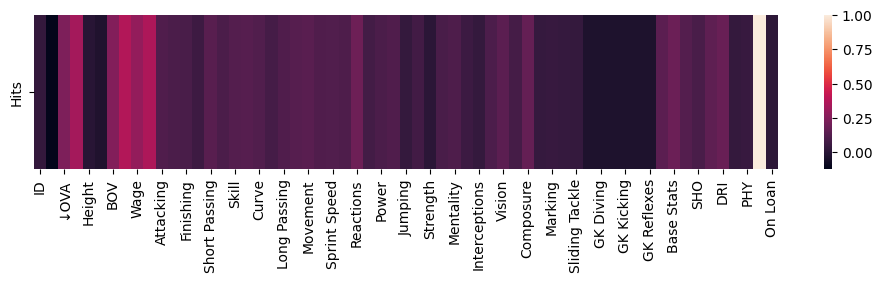

In [72]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(12,2))
sns.heatmap(corr.loc[['Hits']])
# The Hits have no strong correlation with any other feature to predict its value.

In [73]:
# Some players have high popularity and their Hits values are substantially large (outliers).
# Replacing missing values with the mean.

hits_mean=int(df['Hits'].mean())
print(type(hits_mean))

df['Hits']=df['Hits'].apply(

                        lambda x : hits_mean
                        if pd.isnull(x)
                        else int(x)                    
)

<class 'int'>


### Handling inconsistencies in data :
The inconsistencies in 'Height','Weight','Value','Wage' and 'Hits' were already handled.

Handling of 'Contract':

In [74]:
# Upon exploring it is observed that there are 3 types of strings in this column : (YYYY-YYYY), 'Free' and 'Mon DD,YYYY On Loan'
# We already have a column that shows a player is on loan or not. We need to keep contract year end.
def contract_year(string):
    if string=='Free':
        return 0
    elif 'On Loan' in string:
        return int(string[8:12])
    else:
        return int(string[7:11])

df['Contract']=df['Contract'].apply(contract_year)


# TASK D
## Feature Engineering
The task is to :<br>
1. Encode Ordinal attributes.<br>
2. Scaling of attributes.<br>
3. Feature Engineering.

### Feature Transformation :
Encoding of 'Best Position','Nationality' and 'Club':

In [75]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
# The Best Position column has 15 categories. The best way to feed these to a model is to encode them into numbers.
df['Best Position']=le.fit_transform(df['Best Position'])

# There are 164 unique columns (countries) and . Label Coding instead of one hot coding is used because the later will add 164 more columns to our data.
df['Nationality']=le.fit_transform(df['Nationality'])

# Simillarly for the column 'Clubs', it has 684 unique values. 
df['Club']=le.fit_transform(df['Club'])

Handling of 'Preffered Foot':

In [76]:
# It has only 2 values, which we can map
df['Preferred Foot']=df['Preferred Foot'].map({
    'Left':0,
    'Right':1
})

Handling of 'Positions' attribute:<br>
This shows the different positions a player can play. We are going to transform it into number of positions instead of a string of positions. This will transform our data into numerical attribute with a range [1,3].

In [77]:
# It contains the positions as a comma separated string
def pos(string):
    str1=string.split(',')
    return len(str1)
df['Positions']=df['Positions'].apply(pos)


Handling of ordinal attributes (the ratings : A/W and D/W):

In [78]:
# These already have order established.
df['A/W']=df['A/W'].map({
    'Low':0,
    'Medium':1,
    'High':2
})
df['D/W']=df['D/W'].map({
    'Low':0,
    'Medium':1,
    'High':2
})


Handling of Star Ratings (IR, WF and SM) : 

In [79]:
# These columns have star ratings in the form of string. '★' can be replaced and number extracted.
df['IR']=df['IR'].replace('★','',regex=True)
df['W/F']=df['W/F'].replace('★','',regex=True)
df['SM']=df['SM'].replace('★','',regex=True)
df['IR']=df['IR'].astype(int)
df['W/F']=df['W/F'].astype(int)
df['SM']=df['SM'].astype(int)

### Feature Scaling :
Let us see the range of each numeric column:

In [80]:
numeric_col=df.select_dtypes(include=['number']).columns
for col in numeric_col:
    print(f"For {col} :")
    print(f"Range : {df[col].max()-df[col].min()}")
    print(f"Median : {df[col].median()}")
    print()

# For Value, Wage and Release Clause, the range is huge which can dominate in impacting the model learnings.

For ID :
Range : 259175
Median : 232418.0

For Nationality :
Range : 163
Median : 65.0

For Age :
Range : 37
Median : 25.0

For ↓OVA :
Range : 46
Median : 66.0

For POT :
Range : 48
Median : 71.0

For Club :
Range : 681
Median : 344.0

For Contract :
Range : 2028
Median : 2022.0

For Positions :
Range : 2
Median : 1.0

For Height :
Range : 51.0
Median : 181.0

For Weight :
Range : 60.0
Median : 75.0

For Preferred Foot :
Range : 1
Median : 1.0

For BOV :
Range : 45
Median : 67.0

For Best Position :
Range : 14
Median : 5.0

For Value :
Range : 185500000.0
Median : 950000.0

For Wage :
Range : 560000.0
Median : 3000.0

For Release Clause :
Range : 203100000.0
Median : 1000000.0

For Attacking :
Range : 395
Median : 263.0

For Crossing :
Range : 88
Median : 54.0

For Finishing :
Range : 92
Median : 49.0

For Heading Accuracy :
Range : 88
Median : 55.0

For Short Passing :
Range : 87
Median : 62.0

For Volleys :
Range : 87
Median : 44.0

For Skill :
Range : 430
Median : 269.0

For Dribbli

In [81]:
# We will use Min Max scaler to scale these values to be in line with the majority of attributes : [1,100]
from sklearn.preprocessing import MinMaxScaler
mm=MinMaxScaler(feature_range=(1,100))

df[['Value','Wage','Release Clause']]=mm.fit_transform(df[['Value','Wage','Release Clause']])

Creating new features:<br>
Earlier "On Loan" feature was created from 'Loan Date End', simillarly:

In [82]:
# BMI can be created from height and weight. The BMI gives a fitness score for a particular age group and can be directly responsible for performance.
df['BMI']=df['Weight']/((df['Height']/100)**2)
df[['BMI']]=mm.fit_transform(df[['BMI']])

# Total Work = A/W + D/W
df['Total Work']=df['A/W']+df['D/W']
df[['Total Work']]=mm.fit_transform(df[['Total Work']])

# Attack score = pace + shooting + passing + dribling + heading aacuracy + finishing + volleys
df['Attack Score']=df['PAC']+df['SHO']+df['PAS']+df['DRI']+df['Heading Accuracy']+df['Finishing']+df['Volleys']
df[['Attack Score']]=mm.fit_transform(df[['Attack Score']])

# Defence score = DEF + PHY + marking + standing + sliding tackes
df['Defence Score']=df['DEF']+df['PHY']+df['Marking']+df['Standing Tackle']+df['Sliding Tackle']
df[['Defence Score']]=mm.fit_transform(df[['Defence Score']])

### Attribute selection:

In [83]:
# Remove irrelevant columns:
df=df.drop(['ID','Name','LongName','photoUrl','playerUrl','Joined'],axis=1)
df

,Nationality,Age,↓OVA,POT,Club,Contract,Positions,Height,Weight,Preferred Foot,...,PAS,DRI,DEF,PHY,Hits,On Loan,BMI,Total Work,Attack Score,Defence Score
0,6,33,93,93,214,2021,3,170.0,72.0,0,...,91,95,38,65,771,0,44.084651,25.75,98.301471,29.875
1,124,35,92,92,339,2022,2,187.0,83.0,1,...,81,89,35,77,562,0,37.365312,50.50,100.000000,30.425
2,139,27,91,93,64,2023,1,188.0,87.0,1,...,78,90,52,90,150,0,42.383499,50.50,42.492647,31.250
3,14,29,91,91,386,2023,2,181.0,70.0,1,...,93,88,64,78,207,0,23.857819,100.00,85.198529,66.725
4,20,28,91,91,451,2022,2,175.0,68.0,1,...,86,94,36,59,595,0,28.632542,75.25,92.477941,28.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18974,30,21,47,55,670,2022,1,178.0,66.0,1,...,26,38,48,51,26,0,20.800000,50.50,9.977941,44.175
18975,47,17,47,67,432,2021,1,175.0,65.0,1,...,48,49,35,45,26,0,23.045812,50.50,25.992647,30.425
18976,47,18,47,65,189,2020,1,179.0,74.0,1,...,44,46,40,53,26,0,33.715889,50.50,23.566176,35.375
18977,30,20,47,57,178,2022,1,175.0,69.0,1,...,41,49,30,44,26,0,30.494785,50.50,27.691176,24.375


In [84]:
df.rename(columns={'↓OVA':'OVA'},inplace=True)
final_df=df
final_df.to_csv('processed_fifa21.csv')
final_df.shape

(18979, 75)

In [85]:
# Splitting into training and testing data in 80% and 20% ratio:
from sklearn.model_selection import train_test_split

x=final_df.drop('OVA',axis=1)
y=final_df['OVA']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=90)

In [86]:
from sklearn.linear_model import LinearRegression
newlr=LinearRegression()
newlr.fit(x_train,y_train)

y_pred=newlr.predict(x_test)

from sklearn.metrics import mean_absolute_error
score=mean_absolute_error(y_pred,y_test)
print(score)

0.6165145118436469
